In [1]:
# Импортируем библиотеки

import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
cir = pd.read_csv('/content/drive/MyDrive/cirrhosis.csv', sep=',')
cir

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,414,681,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,415,1103,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,416,1055,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,417,691,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [3]:
cir.isnull().sum() #Пропущенные значения

,0
ID,0
N_Days,0
Status,0
Drug,106
Age,0
Sex,0
Ascites,106
Hepatomegaly,106
Spiders,106
Edema,0


In [4]:
cir_cleaned = cir.dropna(subset=['Stage'])

In [8]:
# Автоматически для всех числовых столбцов
numeric_columns = cir_cleaned.select_dtypes(include=[np.number]).columns
cir_cleaned[numeric_columns] = cir_cleaned[numeric_columns].apply(lambda x: x.fillna(x.mean()))

/tmp/ipython-input-2957142065.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cir_cleaned[numeric_columns] = cir_cleaned[numeric_columns].apply(lambda x: x.fillna(x.mean()))


In [9]:
cir_cleaned.isnull().sum() #Пропущенные значения

,0
ID,0
N_Days,0
Status,0
Drug,100
Age,0
Sex,0
Ascites,100
Hepatomegaly,100
Spiders,100
Edema,0


In [10]:
vals = cir_cleaned["Stage"].unique()
vals

array([4., 3., 2., 1.])

In [11]:
# сохраняем только числовые столбцы. Категориальные кодируем в числовые. Целевую переменную (если она есть) - убираем
cols_for_clusters = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']
df= cir[cols_for_clusters].copy() # делаем копию, чтобы не было сюрпризов с исходным набором данных

In [12]:
X = df
y = cir["Stage"].replace(vals, [0, 1, 2, 3])
yvals = cir["Stage"]

In [13]:
df.head()

,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,400,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,4500,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,1012,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,1925,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,1504,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [14]:
import mpl_toolkits.mplot3d  # noqa: F401
from sklearn.cluster import KMeans

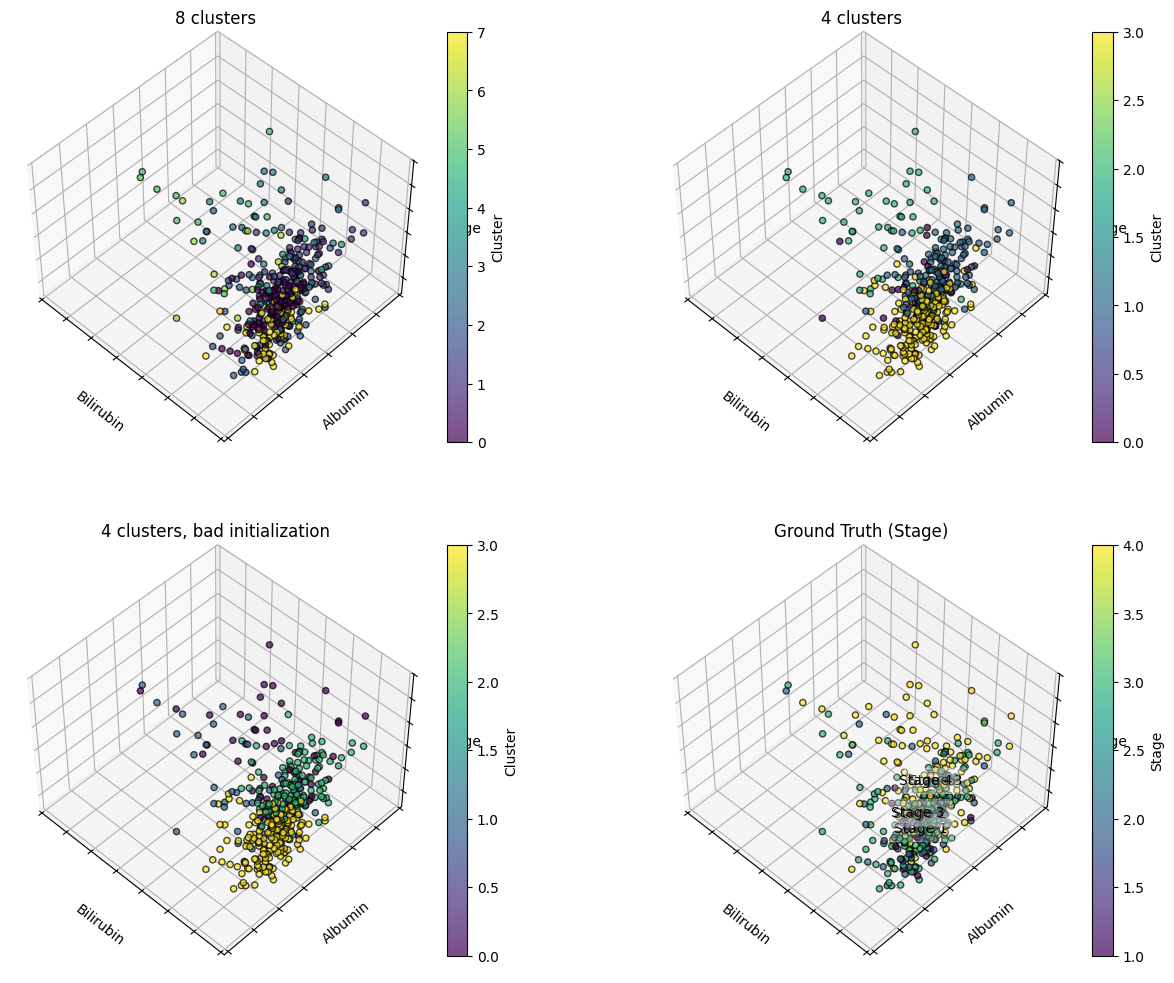

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Загрузка данных (предполагая, что данные уже загружены в DataFrame df)
# df = pd.read_csv('your_data.csv')

# Выберем числовые признаки для кластеризации
numeric_features = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                   'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# Подготовка данных
X = df[numeric_features].copy()

# Заполнение пропущенных значений (если есть)
X = X.fillna(X.mean())

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_features)

# Для 3D визуализации выберем 3 наиболее информативных признака
features_3d = ['Bilirubin', 'Albumin', 'Age']

estimators = [
    ("k_means_8", KMeans(n_clusters=8, random_state=42)),
    ("k_means_4", KMeans(n_clusters=4, random_state=42)),
    ("k_means_bad_init", KMeans(n_clusters=4, n_init=1, init="random", random_state=0)),
]

fig = plt.figure(figsize=(15, 12))
titles = ["8 clusters", "4 clusters", "4 clusters, bad initialization"]

for idx, ((name, est), title) in enumerate(zip(estimators, titles)):
    ax = fig.add_subplot(2, 2, idx + 1, projection="3d", elev=48, azim=134)

    # Используем все признаки для кластеризации, но только 3 для визуализации
    est.fit(X_scaled)
    labels = est.labels_

    scatter = ax.scatter(X_scaled[features_3d[0]],
               X_scaled[features_3d[1]],
               X_scaled[features_3d[2]],
               c=labels.astype(float),
               edgecolor="k",
               alpha=0.7,
               cmap='viridis')

    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xlabel(features_3d[0])
    ax.set_ylabel(features_3d[1])
    ax.set_zlabel(features_3d[2])
    ax.set_title(title)

    # Добавляем цветовую шкалу для кластеров
    plt.colorbar(scatter, ax=ax, label='Cluster')

# Визуализация истинных меток (Stage)
ax = fig.add_subplot(2, 2, 4, projection="3d", elev=48, azim=134)

# Используем Stage как ground truth (только существующие стадии)
valid_stages = [stage for stage in sorted(df['Stage'].unique()) if not pd.isna(stage)]

for stage in valid_stages:
    ds = X_scaled[df['Stage'] == stage]
    if len(ds) > 0:  # Проверяем, что есть данные для этой стадии
        ax.text3D(
            ds[features_3d[0]].mean(),
            ds[features_3d[1]].mean(),
            ds[features_3d[2]].mean(),
            f"Stage {int(stage)}",
            horizontalalignment="center",
            bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
        )

# Визуализация точек с цветами по Stage
scatter = ax.scatter(X_scaled[features_3d[0]],
                     X_scaled[features_3d[1]],
                     X_scaled[features_3d[2]],
                     c=df['Stage'],
                     edgecolor="k",
                     alpha=0.7,
                     cmap='viridis')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel(features_3d[0])
ax.set_ylabel(features_3d[1])
ax.set_zlabel(features_3d[2])
ax.set_title("Ground Truth (Stage)")

# Добавим цветовую шкалу для Stage
plt.colorbar(scatter, ax=ax, label='Stage')

plt.subplots_adjust(wspace=0.25, hspace=0.25)
plt.show()


In [17]:
from sklearn import metrics
from sklearn.metrics.cluster import adjusted_rand_score


n_clusters = np.arange(2, 21)

In [18]:
best_metric = [0, 10000, 0,[]]

silhouette_score_values = []
adjusted_rand_score_values = []


for n in n_clusters:

    clusterer = KMeans(n_clusters=n, max_iter=10, n_init=10)
    clusterer.fit(X)
    y_pred = clusterer.predict(X)

    score1 = metrics.silhouette_score(X, y_pred)
    silhouette_score_values.append(score1)

    score2 = metrics.adjusted_rand_score(y, y_pred)
    adjusted_rand_score_values.append(score2)


    if score1 < best_metric[1] and score2 > best_metric[2]:
          best_metric[1] = score1
          best_metric[2] = score2
          best_metric[3] = clusterer.cluster_centers_
          best_metric[0] = n




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
/usr/local/l

In [19]:
best_metric

[np.int64(2),
 np.float64(0.48121534021991175),
 0.020452237885443633,
 array([[2.15909626e+04, 3.11308411e+00, 3.51891799e+02, 3.44990654e+00,
         1.01416310e+02, 1.87824524e+03, 1.15066069e+02, 1.26784450e+02,
         2.44304427e+02, 1.08205607e+01],
        [1.53258578e+04, 3.33382353e+00, 3.87992992e+02, 3.54730392e+00,
         9.36957622e+01, 2.09218446e+03, 1.30413793e+02, 1.22517730e+02,
         2.70368249e+02, 1.06385464e+01]])]

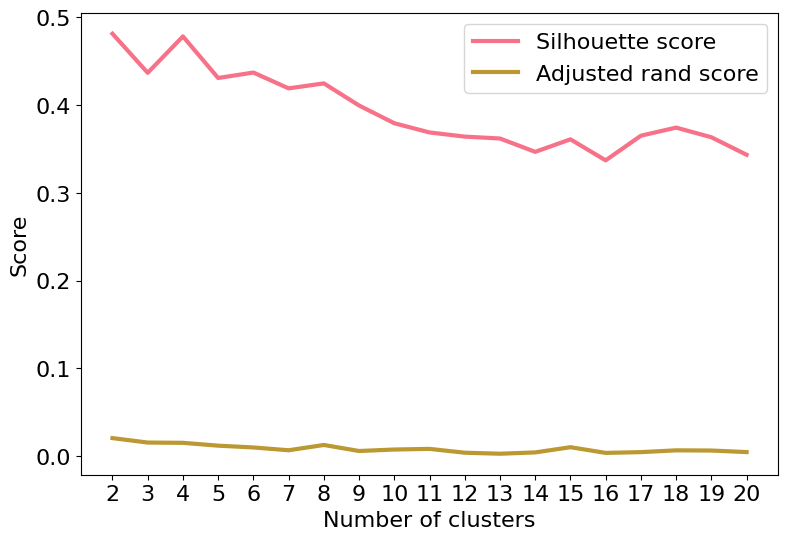

In [20]:
plt.figure(figsize=(9, 6))
plt.plot(n_clusters, silhouette_score_values, linewidth=3, label='Silhouette score')
plt.plot(n_clusters, adjusted_rand_score_values, linewidth=3, label='Adjusted rand score')
plt.xlabel('Number of clusters', size=16)
plt.ylabel('Score', size=16)
plt.xticks(n_clusters, size=16)
plt.yticks(size=16)
plt.legend(loc='best', fontsize=16)

plt.show()


#plt.figure(figsize=(9, 6))
#plt.plot(n_clusters, within_cluster_dist_values, linewidth=3, label='Within-cluster distance')
#plt.xlabel('Number of clusters', size=16)
#plt.ylabel('Score', size=16)
#plt.xticks(n_clusters, size=16)
#plt.yticks(size=16)
#plt.legend(loc='best', fontsize=16)

#plt.show()

# Иерархическая кластеризация

In [21]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [22]:
# Проверим типы данных
print("Типы данных в DataFrame:")
print(df.dtypes)

# Проверим уникальные значения в каждом столбце
print("\nУникальные значения в категориальных столбцах:")
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"{column}: {df[column].unique()}")

# Показать первые несколько строк
print("\nПервые 5 строк данных:")
print(df.head())

Типы данных в DataFrame:
N_Days             int64
Age                int64
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage            float64
Cluster            int32
dtype: object

Уникальные значения в категориальных столбцах:

Первые 5 строк данных:
   N_Days    Age  Bilirubin  Cholesterol  Albumin  Copper  Alk_Phos    SGOT  \
0     400  21464       14.5        261.0     2.60   156.0    1718.0  137.95   
1    4500  20617        1.1        302.0     4.14    54.0    7394.8  113.52   
2    1012  25594        1.4        176.0     3.48   210.0     516.0   96.10   
3    1925  19994        1.8        244.0     2.54    64.0    6121.8   60.63   
4    1504  13918        3.4        279.0     3.53   143.0     671.0  113.15   

   Tryglicerides  Platelets  Prothrombin  Stage  Cluster  
0          172.0      190.0   

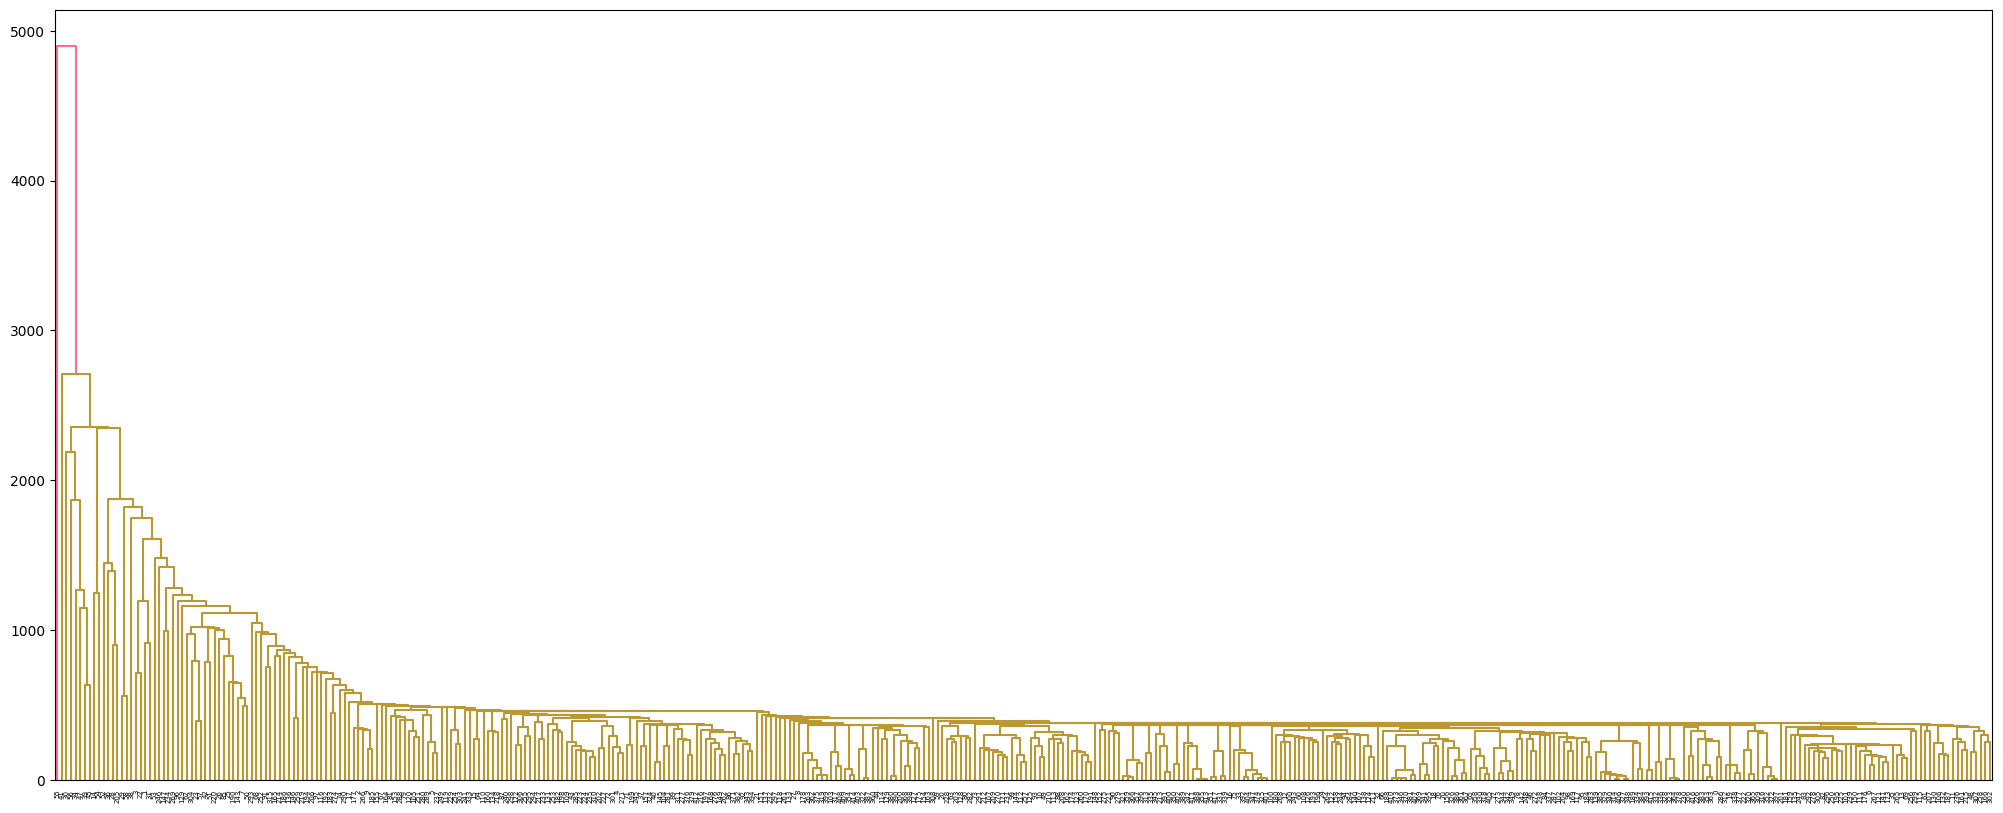

In [23]:
samples = df.values

Z = linkage(X, 'single')
fig = plt.figure(figsize=(25, 10))
dn = dendrogram(Z)
plt.show()

# DBSCAN

In [24]:
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

In [25]:
mins = X.shape[1]

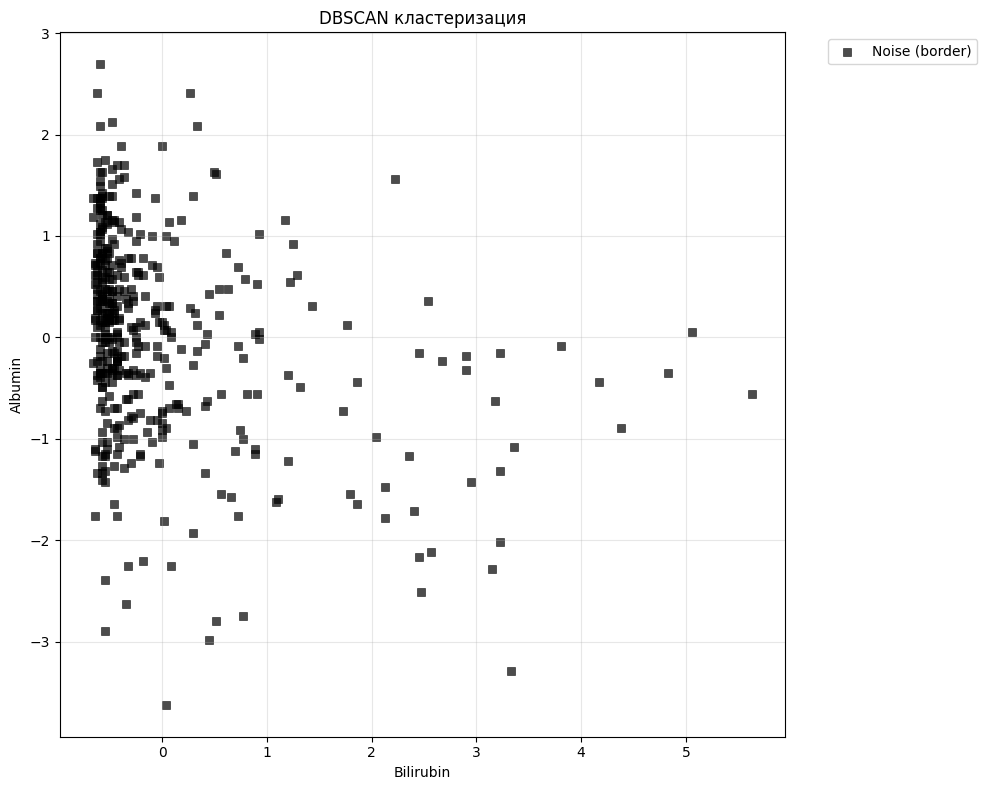

In [26]:

# Выберем числовые признаки для кластеризации
numeric_features = ['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper',
                   'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# Создаем DataFrame с числовыми признаками
X = df[numeric_features].copy()

# Заполняем пропущенные значения
X = X.fillna(X.median())

# Масштабируем данные (важно для DBSCAN!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=numeric_features)

# Выбираем 2 признака для визуализации (например, Billirubin и Albumin)
feature_x = 'Bilirubin'
feature_y = 'Albumin'

# Выполняем DBSCAN кластеризацию
db = DBSCAN(eps=0.5, min_samples=5).fit(X_scaled)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Визуализация результатов
plt.figure(figsize=(10, 8))

# Цвета для кластеров
colors = plt.cm.Set1(np.linspace(0, 1, len(set(labels))))

unique_labels = set(labels)

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Черный для шума
        col = 'k'
        label = 'Noise'
    else:
        label = f'Cluster {k}'

    class_member_mask = (labels == k)

    # Core points (внутренние точки кластеров)
    xy = X_scaled[class_member_mask & core_samples_mask]
    if len(xy) > 0:
        plt.scatter(xy[feature_x], xy[feature_y],
                   c=[col], marker='o',
                   edgecolor='k', s=50, linewidth=0.5,
                   label=label + ' (core)')

    # Border points (граничные точки кластеров)
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    if len(xy) > 0:
        plt.scatter(xy[feature_x], xy[feature_y],
                   c=[col], marker='s',
                   edgecolor='k', s=30, linewidth=0.5,
                   label=label + ' (border)', alpha=0.7)

plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.title(f'DBSCAN кластеризация')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


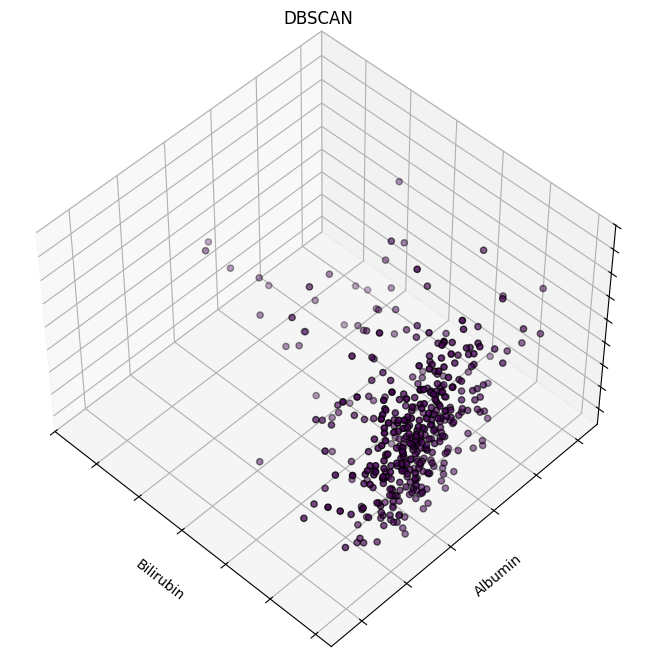

In [29]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter(X["Bilirubin"], X["Albumin"], X["Age"], c=labels.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel("Bilirubin")
ax.set_ylabel("Albumin")
ax.set_zlabel("Age")
ax.set_title("DBSCAN")

plt.show()

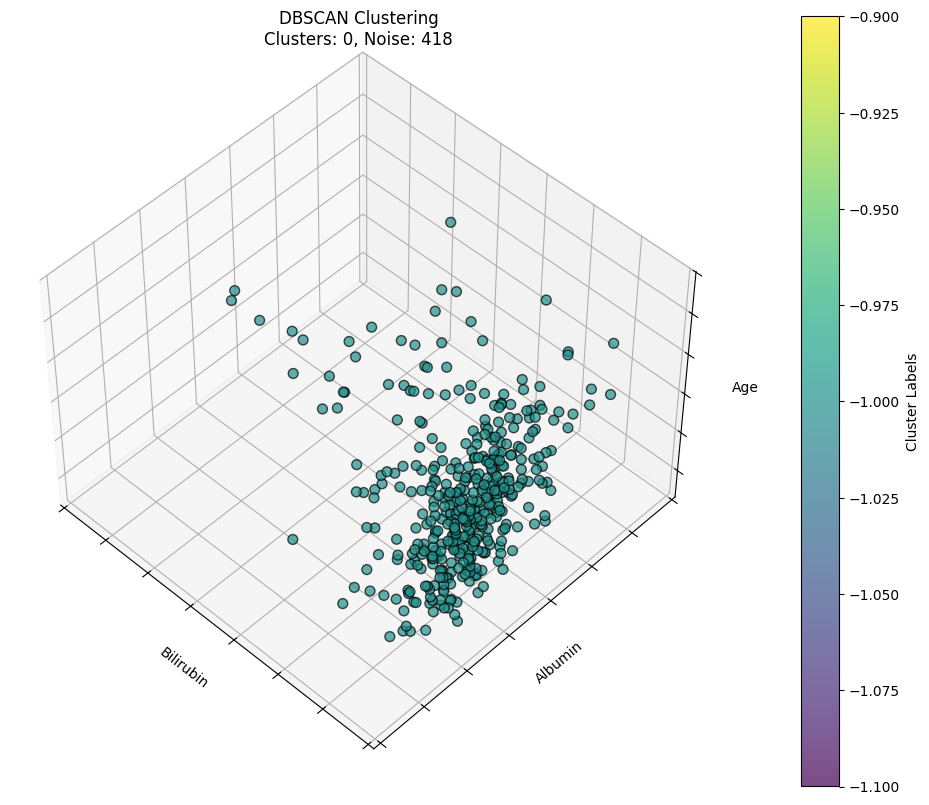

In [28]:
# 3D визуализация
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

# Выбираем три признака для осей (можно изменить)
feature_x = 'Bilirubin'
feature_y = 'Albumin'
feature_z = 'Age'

# Создаем scatter plot с цветами по кластерам
scatter = ax.scatter(X_scaled[feature_x],
                     X_scaled[feature_y],
                     X_scaled[feature_z],
                     c=labels.astype(float),
                     edgecolor="k",
                     alpha=0.7,
                     s=50)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel(feature_x)
ax.set_ylabel(feature_y)
ax.set_zlabel(feature_z)
ax.set_title(f"DBSCAN Clustering\nClusters: {len(set(labels)) - (1 if -1 in labels else 0)}, Noise: {list(labels).count(-1)}")

# Добавляем цветовую шкалу
cbar = plt.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Cluster Labels')

plt.show()